# Band Power: EEG
 We start with a single sine wave, build intuition for what "power" means, learn four ways to measure it (FFT, Welch, Hilbert, Wavelet Transform), and then **confirm everything on real BrainBit & CalmSync data**.


In [69]:
# ── Imports & style ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import signal
from scipy.signal import welch, hilbert
import json, warnings, sys
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Consistent style ────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'figure.dpi':       110,
})

# palette
C_ALPHA  = '#e74c3c'   # red  — alpha band
C_THETA  = '#3498db'   # blue — theta band
C_SIGNAL = '#2c3e50'   # dark — raw signal
C_FP1    = '#2166ac'
C_FP2    = '#d6604d'

BAND_COLORS = {
    'Delta (1-4 Hz)':  '#9b59b6',
    'Theta (4-8 Hz)':  '#3498db',
    'Alpha (8-13 Hz)': '#e74c3c',
    'Beta (13-30 Hz)': '#2ecc71',
    'Gamma (30-40 Hz)':'#f39c12',
}

print("✓ Ready")

✓ Ready


---
## 1 · Power of a Sine Wave — The Intuition

> **Core idea:** Power = how much energy a signal carries at a given frequency.

A pure sine wave at frequency $f$ with amplitude $A$:

$$x(t) = A \sin(2\pi f \, t)$$

Its **power** is simply $\frac{A^2}{2}$. That's it. If $A = 1$, the power is **0.5**.

Let's see it.

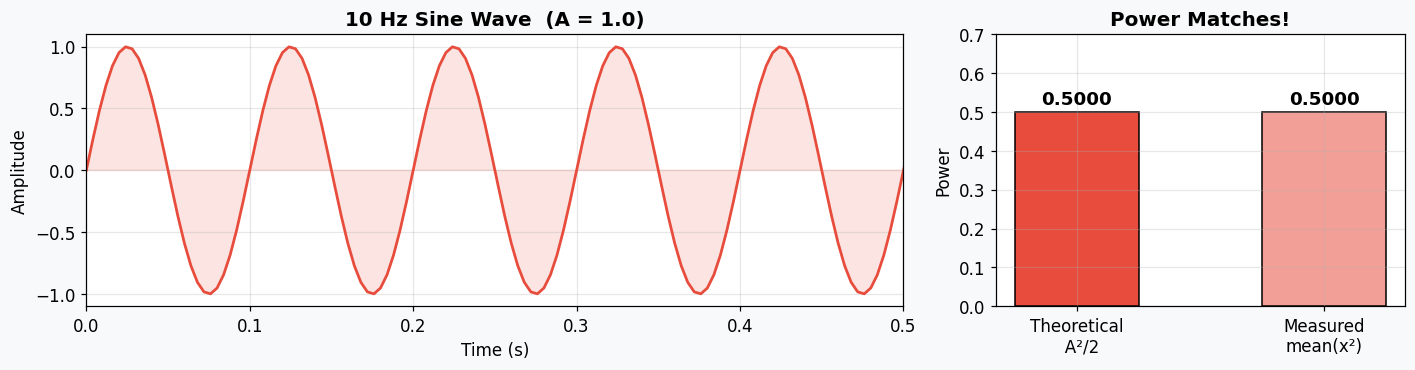

  Theoretical power = A²/2 = 0.5
  Measured power    = mean(x²) = 0.500000


In [29]:
# ── A single 10 Hz sine wave ─────────────────────────────────────────────────
fs   = 250                          # sampling rate (Hz) — same as BrainBit
dur  = 2                            # seconds
t    = np.arange(0, dur, 1/fs)
freq = 10                           # Hz (alpha band)
amp  = 1.0
sine = amp * np.sin(2 * np.pi * freq * t)

# theoretical power
theoretical_power = amp**2 / 2
measured_power    = np.mean(sine**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5), gridspec_kw={'width_ratios': [2, 1]})

# Left: the sine wave
ax = axes[0]
ax.plot(t, sine, color=C_ALPHA, lw=1.8)
ax.fill_between(t, sine, alpha=0.15, color=C_ALPHA)
ax.set(xlabel='Time (s)', ylabel='Amplitude', title=f'{freq} Hz Sine Wave  (A = {amp})')
ax.set_xlim(0, 0.5)

# Right: power bar
ax = axes[1]
bars = ax.bar(['Theoretical\n  A²/2', 'Measured\nmean(x²)'],
              [theoretical_power, measured_power],
              color=[C_ALPHA, '#e74c3c88'], edgecolor='k', width=0.5)
for bar, val in zip(bars, [theoretical_power, measured_power]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
ax.set(ylabel='Power', title='Power Matches!', ylim=(0, 0.7))

plt.tight_layout()
plt.show()
print(f"  Theoretical power = A²/2 = {theoretical_power}")
print(f"  Measured power    = mean(x²) = {measured_power:.6f}")

**Takeaway:** Power is just the *average squared amplitude*. For a pure sine, it's exactly $A^2/2$.

But real EEG has **many frequencies mixed together**. We need methods that can tease apart *how much power lives at each frequency*. That's what PSD (Power Spectral Density) gives us.




## 2 · Methods to compute the oscillatory strength over time and frequency



### 2a · FFT — The Foundation

> **Idea:** Decompose the entire signal into its constituent frequencies using the Discrete Fourier Transform. 
**Pros:** Direct, no parameters to tune, shows you exactly what frequencies are present.  
**Cons:** Noisy (high variance) — a single FFT of a noisy signal gives a jagged spectrum.


![FFT](images/FFT.jpeg)


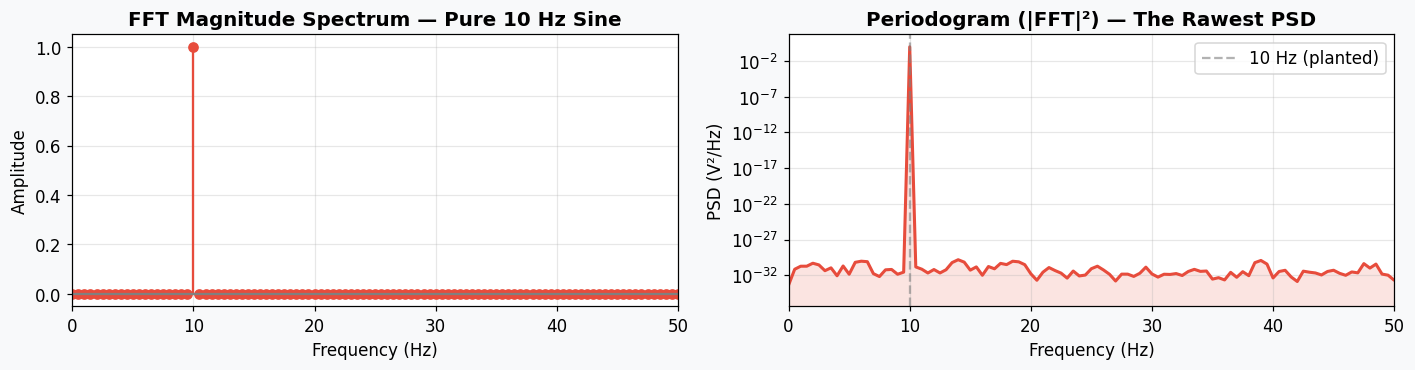

  → Clean sine = clean spike. But on noisy signals this periodogram gets very jagged.
    That's why we need Welch / Multitaper to smooth it.


In [70]:
# ── Raw FFT (periodogram) on the pure 10 Hz sine ────────────────────────────
N    = len(sine)
freqs_fft = np.fft.rfftfreq(N, 1/fs)
fft_vals  = np.fft.rfft(sine)
psd_fft   = (2.0 / (N * fs)) * np.abs(fft_vals)**2   # one-sided PSD



fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))

# Left: magnitude spectrum (linear)
ax = axes[0]
ax.stem(freqs_fft, np.abs(fft_vals) * 2/N, linefmt=C_ALPHA, markerfmt='o', basefmt='grey')
ax.set(xlabel='Frequency (Hz)', ylabel='Amplitude',
       title='FFT Magnitude Spectrum — Pure 10 Hz Sine', xlim=(0, 50))

# Right: periodogram (log scale, like a PSD)
ax = axes[1]
ax.semilogy(freqs_fft, psd_fft, color=C_ALPHA, lw=2)
ax.fill_between(freqs_fft, psd_fft, alpha=0.15, color=C_ALPHA)
ax.axvline(10, ls='--', color='grey', alpha=0.6, label='10 Hz (planted)')
ax.set(xlabel='Frequency (Hz)', ylabel='PSD (V²/Hz)',
       title='Periodogram (|FFT|²) — The Rawest PSD', xlim=(0, 50))
ax.legend()

plt.tight_layout()
plt.show()
print("  → Clean sine = clean spike. But on noisy signals this periodogram gets very jagged.")
print("    That's why we need Welch / Multitaper to smooth it.")



### 2b · Welch's Method : Stable Power Estimation

> **Idea:** divide the signal into overlapping windows → compute FFT in each window → average them.

**Pros:** smooth estimate.  
**Cons:** No time resolution — gives you one spectrum for the whole segment.

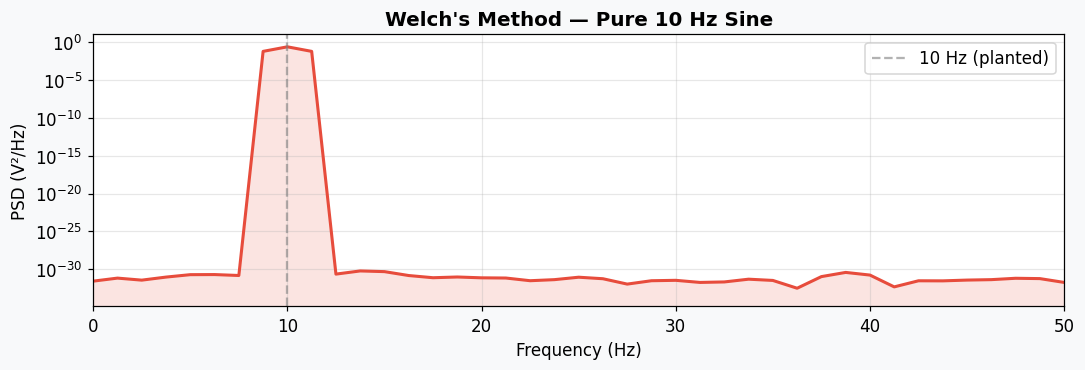

  → Sharp peak exactly at 10 Hz. Welch correctly finds all the power there.


In [72]:
# ── Welch on a pure 10 Hz sine ───────────────────────────────────────────────
freqs_w, psd_w = welch(sine, fs=fs, nperseg=200, noverlap=18)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.semilogy(freqs_w, psd_w, color=C_ALPHA, lw=2)
ax.axvline(10, ls='--', color='grey', alpha=0.6, label='10 Hz (planted)')
ax.fill_between(freqs_w, psd_w, alpha=0.15, color=C_ALPHA)
ax.set(xlabel='Frequency (Hz)', ylabel='PSD (V²/Hz)',
       title="Welch's Method — Pure 10 Hz Sine", xlim=(0, 50))
ax.legend()
plt.tight_layout()
plt.show()
print("  → Sharp peak exactly at 10 Hz. Welch correctly finds all the power there.")

### 2c · Wavelet Transform (time-frequency decomposition)

EEG is a non stationary signal

> **Idea:** Convolve the signal with Morlet wavelets at each frequency of interest. Each wavelet is a short oscillation windowed by a Gaussian, giving you power at a specific frequency *and* time point.

**Pros:** Full time-frequency resolution — see which frequencies are active and *when*. Natural for non-stationary signals like EEG.  
**Cons:** Trade-off between time and frequency resolution (controlled by `n_cycles`). More computationally expensive than Welch.

![Wavelet transform](images/Wavelet_transform.png)


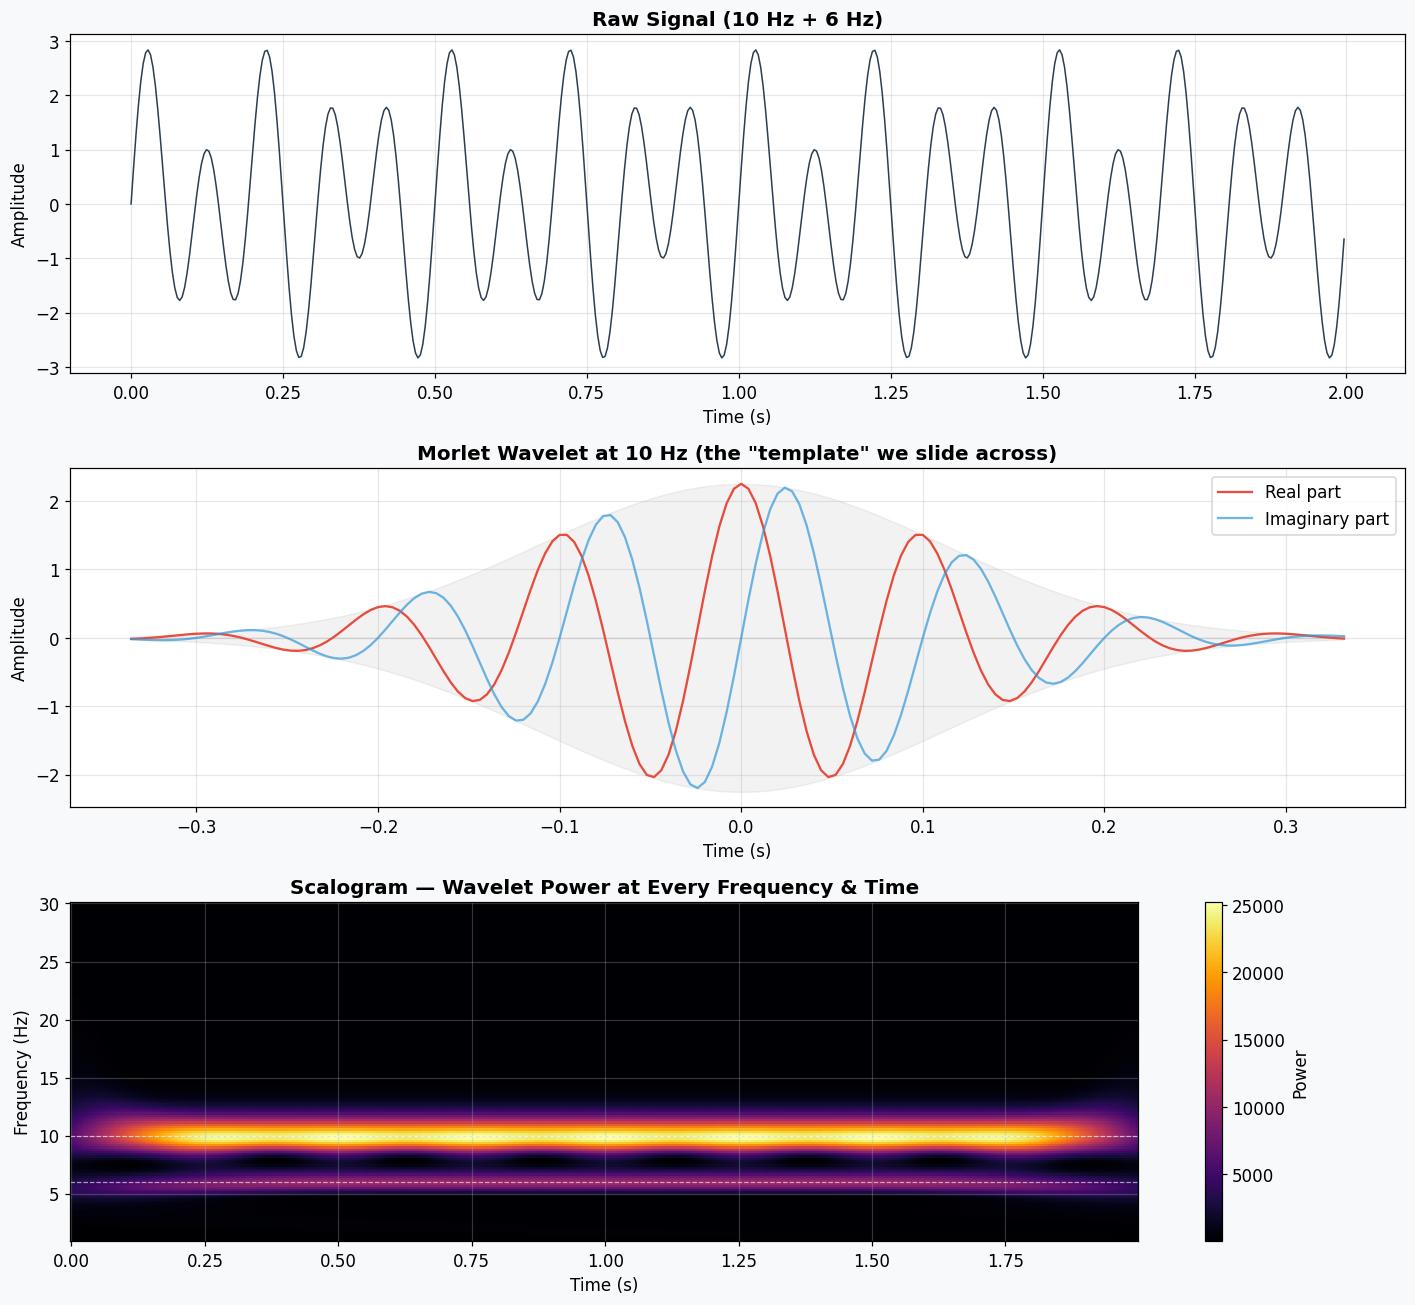

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# ── Synthetic signal: two components ─────────────────────────────────────────
fs  = 250
dur = 2
t   = np.arange(0, dur, 1/fs)

x = 2.0 * np.sin(2 * np.pi * 10 * t) + 1.0 * np.sin(2 * np.pi * 6 * t)

# ── Morlet wavelet function ─────────────────────────────────────────────────
def morlet_wavelet(freq, fs, n_cycles=7):
    """Create a complex Morlet wavelet centred at `freq`."""
    sigma_t = n_cycles / (2 * np.pi * freq)
    n_pts = int(6 * sigma_t * fs)
    if n_pts % 2 == 0:
        n_pts += 1
    t_wav = np.arange(-n_pts // 2, n_pts // 2 + 1) / fs
    wavelet = (np.exp(2j * np.pi * freq * t_wav)
               * np.exp(-t_wav**2 / (2 * sigma_t**2)))
    wavelet /= np.sqrt(sigma_t * np.sqrt(np.pi))
    return t_wav, wavelet

# ── Convolution at a single frequency (10 Hz) ───────────────────────────────
freq_probe = 10
t_wav, wav = morlet_wavelet(freq_probe, fs)
conv_10 = np.convolve(x, wav, mode='same')

# ── Full scalogram across frequencies ────────────────────────────────────────
freqs = np.linspace(1, 30, 150)
scalogram = np.zeros((len(freqs), len(t)))

for i, freq in enumerate(freqs):
    _, w = morlet_wavelet(freq, fs)
    if len(w) > len(x):
        # wavelet longer than signal — zero-pad signal instead
        c = np.convolve(w, x, mode='same')[:len(t)]
    else:
        c = np.convolve(x, w, mode='same')
    scalogram[i, :] = np.abs(c) ** 2


# ── Extracted power at 6 Hz and 10 Hz ───────────────────────────────────────
_, w6 = morlet_wavelet(6, fs)
_, w10 = morlet_wavelet(10, fs)
power_6  = np.abs(np.convolve(x, w6,  mode='same')) ** 2
power_10 = np.abs(np.convolve(x, w10, mode='same')) ** 2

# ── Plot: 4 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)

# 1) Raw signal
axes[0].plot(t, x, color='#2c3e50', lw=1)
axes[0].set(xlabel='Time (s)', ylabel='Amplitude', title='Raw Signal (10 Hz + 6 Hz)')

# 2) The Morlet wavelet itself
axes[1].plot(t_wav, np.real(wav), color='#e74c3c', lw=1.5, label='Real part')
axes[1].plot(t_wav, np.imag(wav), color='#3498db', lw=1.5, alpha=0.7, label='Imaginary part')
axes[1].fill_between(t_wav, np.abs(wav), alpha=0.1, color='grey')
axes[1].fill_between(t_wav, -np.abs(wav), alpha=0.1, color='grey')
axes[1].set(xlabel='Time (s)', ylabel='Amplitude',
            title=f'Morlet Wavelet at {freq_probe} Hz (the "template" we slide across)')
axes[1].legend(loc='upper right')

# 3) Scalogram (time-frequency power)
im = axes[2].pcolormesh(t, freqs, scalogram, shading='auto', cmap='inferno')
axes[2].axhline(10, ls='--', color='white', alpha=0.6, lw=0.8)
axes[2].axhline(6,  ls='--', color='white', alpha=0.6, lw=0.8)
axes[2].set(xlabel='Time (s)', ylabel='Frequency (Hz)',
            title='Scalogram — Wavelet Power at Every Frequency & Time')
fig.colorbar(im, ax=axes[2], label='Power')



plt.tight_layout()
plt.show()


### 2d · Hilbert Transform (instantaneous power)

> **Idea:** Compute the analytic signal → its envelope gives *instantaneous amplitude* at each time point.  
> Bandpass-filter first, then apply Hilbert to get power **over time** within that band.

**Pros:** Time-resolved — you can see power fluctuate moment by moment.  
**Cons:** Requires bandpass filtering first (choice of band is baked in).

![Hilbert transform](images/hilberttransform.png)


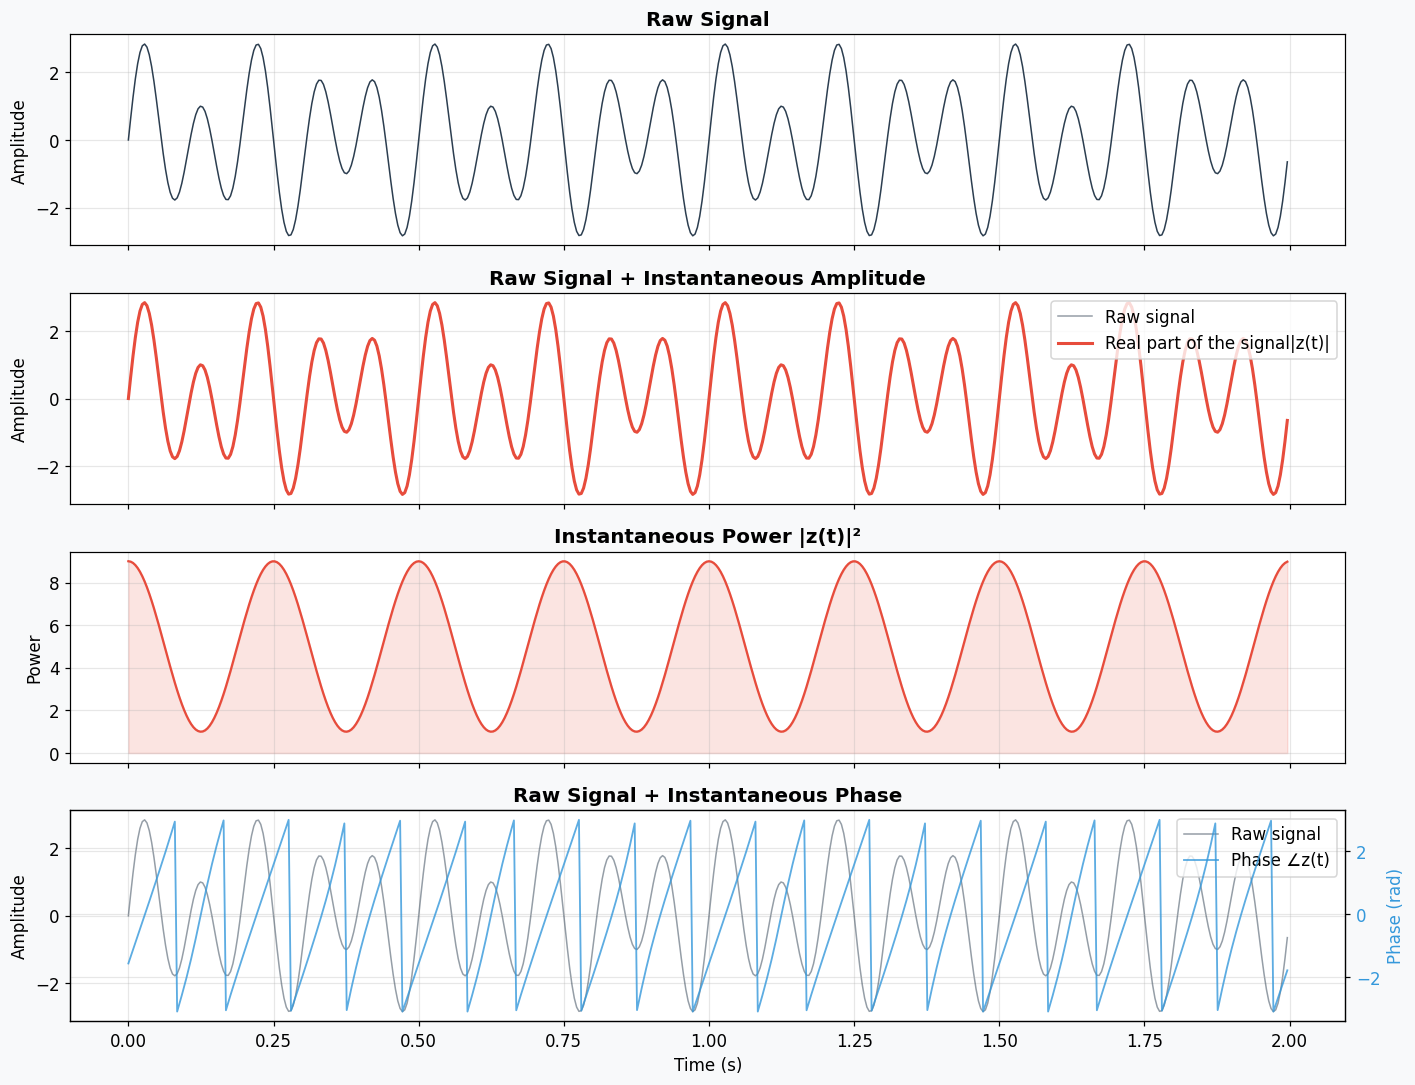

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# ── Synthetic signal: two components ─────────────────────────────────────────
fs  = 250
dur = 2
t   = np.arange(0, dur, 1/fs)

x = 2.0 * np.sin(2 * np.pi * 10 * t) + 1.0 * np.sin(2 * np.pi * 6 * t)

# ── Analytic signal z(t) ────────────────────────────────────────────────────
z = hilbert(x)
real = np.real(z)
inst_amp   = np.abs(z)
inst_power = inst_amp ** 2
inst_phase = np.angle(z)  # no unwrap

# ── Plot: 4 panels ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)

# 1) Raw signal
axes[0].plot(t, x, color='#2c3e50', lw=1)
axes[0].set(ylabel='Amplitude', title='Raw Signal')

# 2) Raw signal + real part of analytic signal (envelope)
axes[1].plot(t, x, color='#2c3e50', lw=1, alpha=0.5, label='Raw signal')
axes[1].plot(t, real, color='#e74c3c', lw=2, label='Real part of the signal|z(t)|')
# axes[1].plot(t, -inst_amp, color='#e74c3c', lw=2, alpha=0.4)
axes[1].set(ylabel='Amplitude', title='Raw Signal + Instantaneous Amplitude')
axes[1].legend(loc='upper right')

# 3) Instantaneous power
axes[2].plot(t, inst_power, color='#e74c3c', lw=1.5)
axes[2].fill_between(t, inst_power, alpha=0.15, color='#e74c3c')
axes[2].set(ylabel='Power', title='Instantaneous Power |z(t)|²')

# 4) Raw signal + phase
ax4 = axes[3]
ax4.plot(t, x, color='#2c3e50', lw=1, alpha=0.5, label='Raw signal')
ax_phase = ax4.twinx()
ax_phase.plot(t, inst_phase, color='#3498db', lw=1.2, alpha=0.8, label='Phase ∠z(t)')
ax4.set(xlabel='Time (s)', ylabel='Amplitude', title='Raw Signal + Instantaneous Phase')
ax_phase.set_ylabel('Phase (rad)', color='#3498db')
ax_phase.tick_params(axis='y', labelcolor='#3498db')
lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax_phase.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()


---
## 3 · Synthetic Signal

We build a signal where we **know the ground truth**:
- **10 Hz** (alpha) with amplitude **2.0**
- **6 Hz** (theta) with amplitude **1.0**
- Gaussian noise (σ = 0.5)

Expected power: α = $2^2/2 = 2.0$, θ = $1^2/2 = 0.5$.

Now we apply all three methods and see if they **rediscover** what we planted.

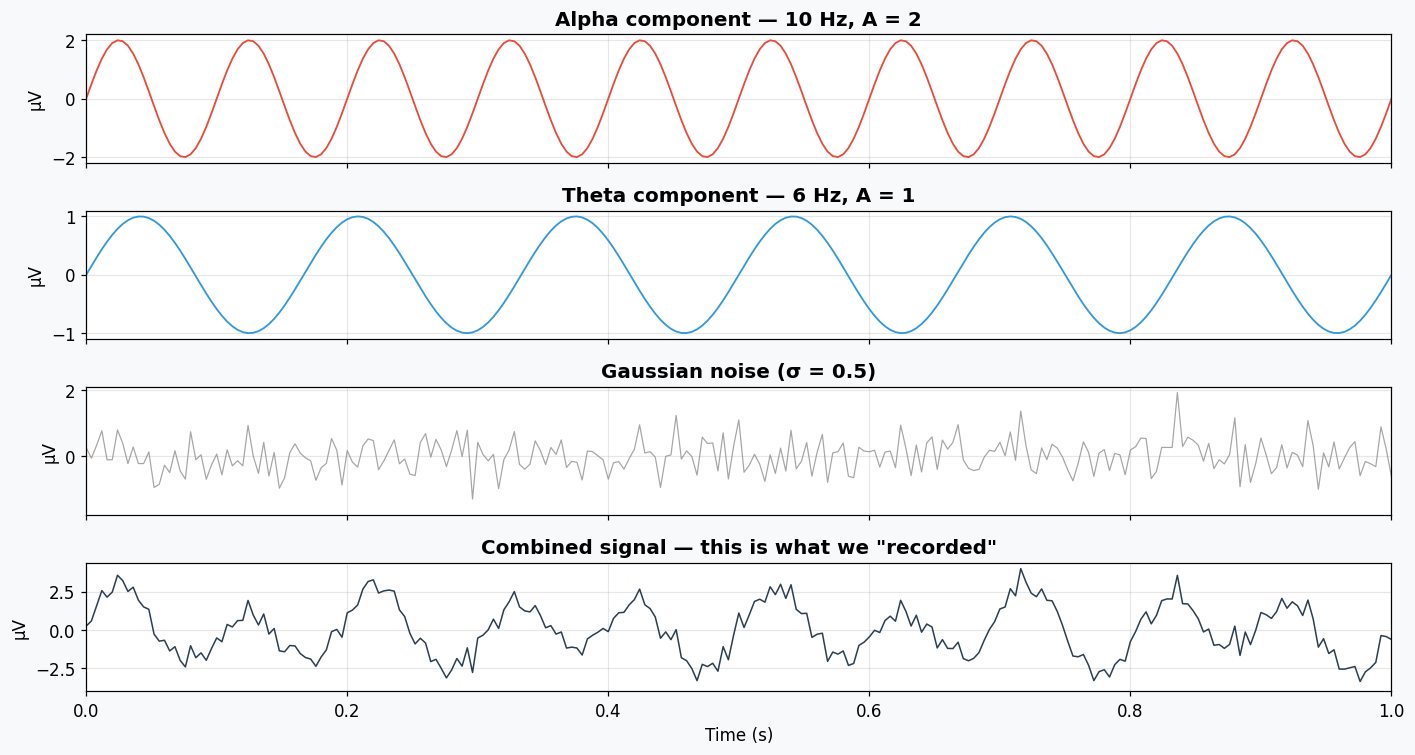

  Ground truth → Alpha power = 2.0,  Theta power = 0.5


In [ ]:
# ── Build synthetic EEG-like signal ──────────────────────────────────────────
np.random.seed(42)
fs_synth = 250
dur_synth = 4                              # seconds (enough for good resolution)
t_synth = np.arange(0, dur_synth, 1/fs_synth)

alpha_comp = 2.0 * np.sin(2 * np.pi * 10 * t_synth)   # 10 Hz, A=2
theta_comp = 1.0 * np.sin(2 * np.pi *  6 * t_synth)   #  6 Hz, A=1
noise      = 0.5 * np.random.randn(len(t_synth))

synth = alpha_comp + theta_comp + noise

# ── Visualise components ─────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(13, 7), sharex=True)

axes[0].plot(t_synth, alpha_comp, color=C_ALPHA, lw=1.2)
axes[0].set(ylabel='µV', title='Alpha component — 10 Hz, A = 2')
axes[0].set_xlim(0, 1)

axes[1].plot(t_synth, theta_comp, color=C_THETA, lw=1.2)
axes[1].set(ylabel='µV', title='Theta component — 6 Hz, A = 1')

axes[2].plot(t_synth, noise, color='grey', lw=0.8, alpha=0.7)
axes[2].set(ylabel='µV', title='Gaussian noise (σ = 0.5)')

axes[3].plot(t_synth, synth, color=C_SIGNAL, lw=1)
axes[3].set(xlabel='Time (s)', ylabel='µV', title='Combined signal — this is what we "recorded"')

for ax in axes:
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()
print("  Ground truth → Alpha power = 2.0,  Theta power = 0.5")

### 3a · All Four Methods Side by Side on the Synthetic Signal

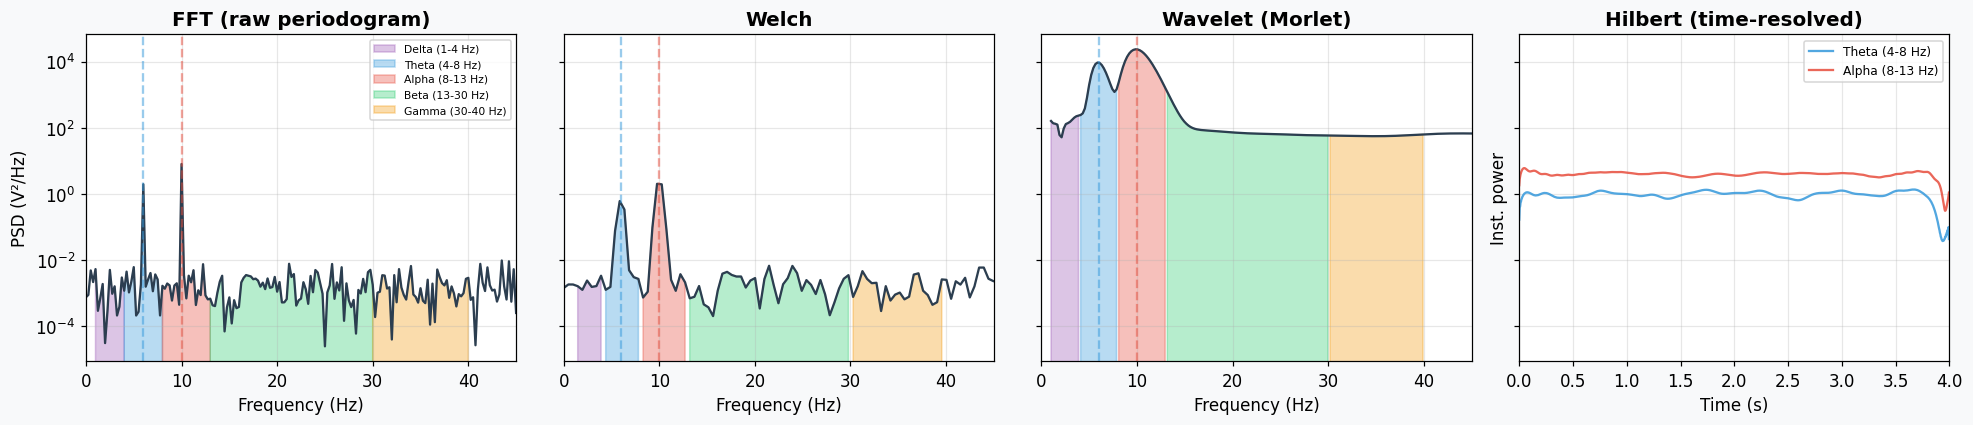

In [77]:
# ── Helper: band power from PSD ──────────────────────────────────────────────
def bandpower_from_psd(freqs, psd, fmin, fmax):
    """Integrate PSD between fmin and fmax using the trapezoidal rule."""
    mask = (freqs >= fmin) & (freqs <= fmax)
    return np.trapz(psd[mask], freqs[mask])

# ── EEG frequency bands ─────────────────────────────────────────────────────
BANDS = {
    'Delta (1-4 Hz)':   (1,  4),
    'Theta (4-8 Hz)':   (4,  8),
    'Alpha (8-13 Hz)':  (8,  13),
    'Beta (13-30 Hz)':  (13, 30),
    'Gamma (30-40 Hz)': (30, 40),
}

# ── Compute PSDs ─────────────────────────────────────────────────────────────
N_synth    = len(synth)
freqs_fft  = np.fft.rfftfreq(N_synth, 1/fs_synth)
psd_fft    = (2.0 / (N_synth * fs_synth)) * np.abs(np.fft.rfft(synth))**2

fw, pw = welch(synth, fs=fs_synth, nperseg=512, noverlap=256)

fwav, pwav = wavelet_psd(synth, fs_synth, freqs=np.linspace(1, 45, 200))

# ── Hilbert per-band power ───────────────────────────────────────────────────
def hilbert_band_power(x, fs, fmin, fmax):
    sos = signal.butter(4, [fmin, fmax], btype='band', fs=fs, output='sos')
    filtered = signal.sosfiltfilt(sos, x)
    return np.mean(np.abs(hilbert(filtered))**2)

# ── All four methods side by side ────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

psd_panels = [
    (freqs_fft, psd_fft, "FFT (raw periodogram)"),
    (fw, pw, "Welch"),
    (fwav, pwav, "Wavelet (Morlet)"),
]

for col, (f, p, title) in enumerate(psd_panels):
    ax = axes[col]
    mask = f <= 45
    ax.semilogy(f[mask], p[mask], color=C_SIGNAL, lw=1.5)
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi) & (f <= 45)
        ax.fill_between(f[bmask], p[bmask], alpha=0.35, color=BAND_COLORS[bname],
                        label=bname if col == 0 else None)
    ax.axvline(6,  ls='--', color=C_THETA, alpha=0.5)
    ax.axvline(10, ls='--', color=C_ALPHA, alpha=0.5)
    ax.set(xlabel='Frequency (Hz)', title=title, xlim=(0, 45))
    if col == 0:
        ax.set_ylabel('PSD (V²/Hz)')
        ax.legend(fontsize=7, loc='upper right')

# Hilbert time-resolved panel
ax = axes[3]
for bname, (lo, hi) in [('Theta (4-8 Hz)', (4, 8)), ('Alpha (8-13 Hz)', (8, 13))]:
    sos = signal.butter(4, [lo, hi], btype='band', fs=fs_synth, output='sos')
    filt = signal.sosfiltfilt(sos, synth)
    env  = np.abs(hilbert(filt))**2
    ax.plot(t_synth, env, lw=1.5, color=BAND_COLORS[bname], label=bname, alpha=0.85)
ax.set(xlabel='Time (s)', ylabel='Inst. power', title='Hilbert (time-resolved)', xlim=(0, dur_synth))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Key takeaway:** All four methods find the alpha peak at 10 Hz and theta at 6 Hz — exactly what we planted. The bar chart shows they agree on band power values. Now let's see what happens with **real brain data**.

---
## 4 · Real Data: BrainBit & CalmSync

We load continuous EEG from both devices, apply the same four methods, and see what the **actual brain** looks like compared to our synthetic signal.

**Devices:**
| | BrainBit | CalmSync |
|---|----------|----------|
| Channels | Fp1, Fp2 | Fp1, Fp2 |
| Sampling rate | ~250 Hz | ~240 Hz |
| Format | XDF (LSL) | JSON |

In [ ]:
# ── Load BrainBit (XDF) ──────────────────────────────────────────────────────
# ── Load BrainBit (XDF) ──────────────────────────────────────────────────────
import pyxdf

xdf_path = r"C:\Users\bwsin\Desktop\Osis_data\Data\Brainbit\Archi_27febgoodbadimages.xdf"
streams, _ = pyxdf.load_xdf(xdf_path)

# find EEG stream by type (not sample_count)
eeg_stream = None
for s in streams:
    if s['info']['type'][0].lower() == 'eeg' and len(s['time_stamps']) > 0:
        eeg_stream = s
        break

raw_data = np.array(eeg_stream['time_series']).T          # (n_ch, n_samples)
eeg_ts   = np.array(eeg_stream['time_stamps'])

# actual fs from timestamps (more reliable than nominal_srate)
bb_fs = float(1.0 / np.median(np.diff(eeg_ts - eeg_ts[0])))

# BrainBit channel order from config
BB_CHAN_NAMES = ['Fz', 'F3', 'Cz', 'F4', 'Pz', 'Fp1', 'Fp2', 'Oz']
fp1_idx = BB_CHAN_NAMES.index('Fp1')
fp2_idx = BB_CHAN_NAMES.index('Fp2')

bb_fp1 = raw_data[fp1_idx, :].astype(float)
bb_fp2 = raw_data[fp2_idx, :].astype(float)

# unit scaling — raw BrainBit is NOT in µV
max_abs = np.max(np.abs(raw_data))
if max_abs < 1.0:          # Volts
    bb_fp1 *= 1e6
    bb_fp2 *= 1e6
    print(f"  Units: Volts detected (max={max_abs:.4f}) → scaled to µV")
elif max_abs <= 1000:       # millivolts
    bb_fp1 *= 1e3
    bb_fp2 *= 1e3
    print(f"  Units: mV detected (max={max_abs:.2f}) → scaled to µV")
else:
    print(f"  Units: already µV (max={max_abs:.1f})")

print(f"  BrainBit: fs = {bb_fs:.1f} Hz, duration = {len(bb_fp1)/bb_fs:.1f} s")


# ── Load CalmSync (JSON) ────────────────────────────────────────────────────
json_path = r"C:\Users\bwsin\Desktop\Osis_data\Data\Calmsync\eeg_2026-02-27T16-33-22_2026-02-27T16-36-16.json"
with open(json_path) as f:
    cs_json = json.load(f)

cs_fs   = cs_json['samplingRateHz']
cs_raw  = np.array(cs_json['data'], dtype=float)     # (2, N)

# ADC → µV conversion
cs_fp1 = ((cs_raw[0] - 512) * 3.3 / 1024) / 1100 * 1e6
cs_fp2 = ((cs_raw[1] - 512) * 3.3 / 1024) / 1100 * 1e6

# ── Filter helper ────────────────────────────────────────────────────────────
def preprocess(x, fs, hp=0.1, lp=45.0, notch=50.0):
    """Bandpass 0.1-45 Hz + 50 Hz notch filter, then DC removal."""
    sos_bp = signal.butter(4, [hp, lp], btype='band', fs=fs, output='sos')
    x = signal.sosfiltfilt(sos_bp, x)
    b, a = signal.iirnotch(notch, Q=30, fs=fs)
    x = signal.filtfilt(b, a, x)
    x -= x.mean()
    return x

# ── Apply to all channels ───────────────────────────────────────────────────
bb_fp1 = preprocess(bb_fp1, bb_fs)
bb_fp2 = preprocess(bb_fp2, bb_fs)
cs_fp1 = preprocess(cs_fp1, cs_fs)
cs_fp2 = preprocess(cs_fp2, cs_fs)

print(f"  BrainBit loaded & filtered: {len(bb_fp1)} samples, fs = {bb_fs:.1f} Hz, "
      f"duration = {len(bb_fp1)/bb_fs:.1f} s")
print(f"  CalmSync loaded & filtered: {len(cs_fp1)} samples, fs = {cs_fs:.1f} Hz, "
      f"duration = {len(cs_fp1)/cs_fs:.1f} s")


  Units: Volts detected (max=0.2204) → scaled to µV
  BrainBit: fs = 249.6 Hz, duration = 182.0 s
  BrainBit loaded & filtered: 45440 samples, fs = 249.6 Hz, duration = 182.0 s
  CalmSync loaded & filtered: 41646 samples, fs = 239.7 Hz, duration = 173.7 s


### 4a · Raw Signal Preview (first 5 seconds)

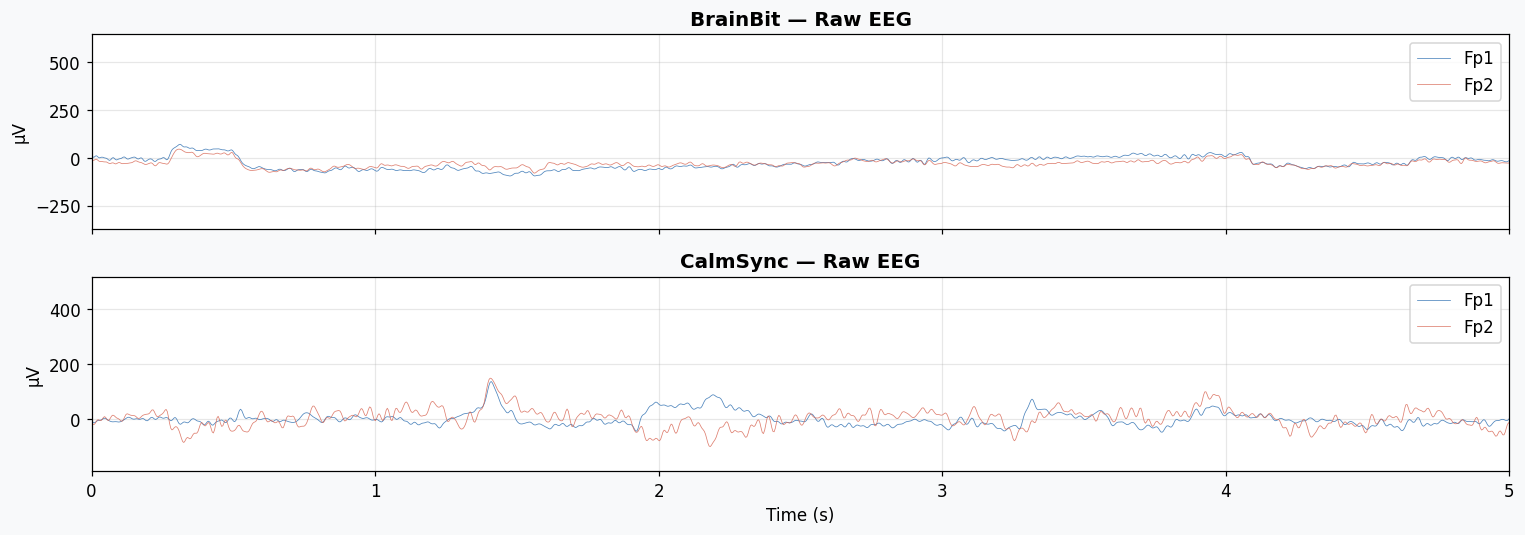

In [ ]:
# ── Quick look at raw signals ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

t_bb = np.arange(len(bb_fp1)) / bb_fs
t_cs = np.arange(len(cs_fp1)) / cs_fs

axes[0].plot(t_bb, bb_fp1, color=C_FP1, lw=0.5, alpha=0.8, label='Fp1')
axes[0].plot(t_bb, bb_fp2, color=C_FP2, lw=0.5, alpha=0.8, label='Fp2')
axes[0].set(ylabel='µV', title='BrainBit — Raw EEG')
axes[0].legend(loc='upper right')
axes[0].set_xlim(0, 5)

axes[1].plot(t_cs, cs_fp1, color=C_FP1, lw=0.5, alpha=0.8, label='Fp1')
axes[1].plot(t_cs, cs_fp2, color=C_FP2, lw=0.5, alpha=0.8, label='Fp2')
axes[1].set(xlabel='Time (s)', ylabel='µV', title='CalmSync — Raw EEG')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 4b · Welch PSD — BrainBit vs CalmSync (Fp1)


BrainBit — Band Powers (Fp1):
  Delta (1-4 Hz)      : 1220.2890 µV²
  Theta (4-8 Hz)      : 164.4816 µV²
  Alpha (8-13 Hz)     : 38.9057 µV²
  Beta (13-30 Hz)     : 13.7880 µV²
  Gamma (30-40 Hz)    : 2.9087 µV²

CalmSync — Band Powers (Fp1):
  Delta (1-4 Hz)      : 103.7628 µV²
  Theta (4-8 Hz)      : 29.0138 µV²
  Alpha (8-13 Hz)     : 13.8548 µV²
  Beta (13-30 Hz)     : 20.6526 µV²
  Gamma (30-40 Hz)    : 5.4854 µV²


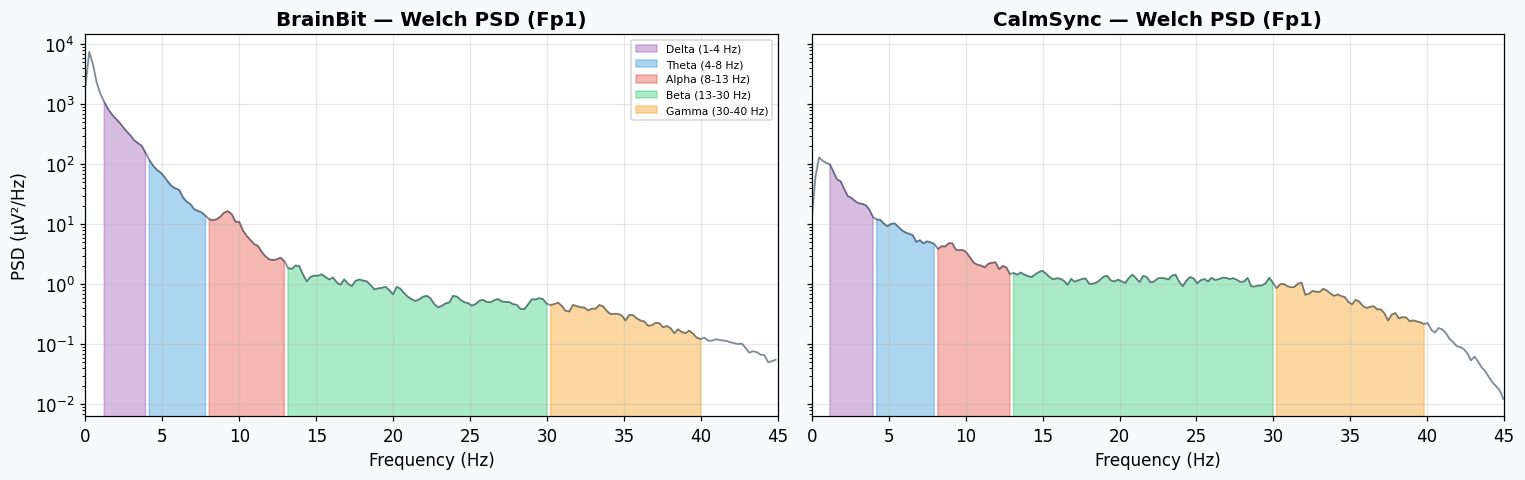

In [79]:
# ── Welch PSD for both devices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (data, fs_dev, name) in zip(axes, [
    (bb_fp1, bb_fs, 'BrainBit'),
    (cs_fp1, cs_fs, 'CalmSync'),
]):
    f, p = welch(data, fs=fs_dev, nperseg=1024, noverlap=512)
    mask = f <= 45
    f, p = f[mask], p[mask]

    ax.semilogy(f, p, color=C_SIGNAL, lw=1.2, alpha=0.6)
    print(f"\n{name} — Band Powers (Fp1):")
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi)
        ax.fill_between(f[bmask], p[bmask], alpha=0.4, color=BAND_COLORS[bname], label=bname)
        band_power = np.trapz(p[bmask], f[bmask])
        print(f"  {bname:20s}: {band_power:.4f} µV²")
    ax.set(xlabel='Frequency (Hz)', title=f'{name} — Welch PSD (Fp1)', xlim=(0, 45))

axes[0].set_ylabel('PSD (µV²/Hz)')
axes[0].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()


### 4c · Wavelet PSD — BrainBit vs CalmSync (Fp1)

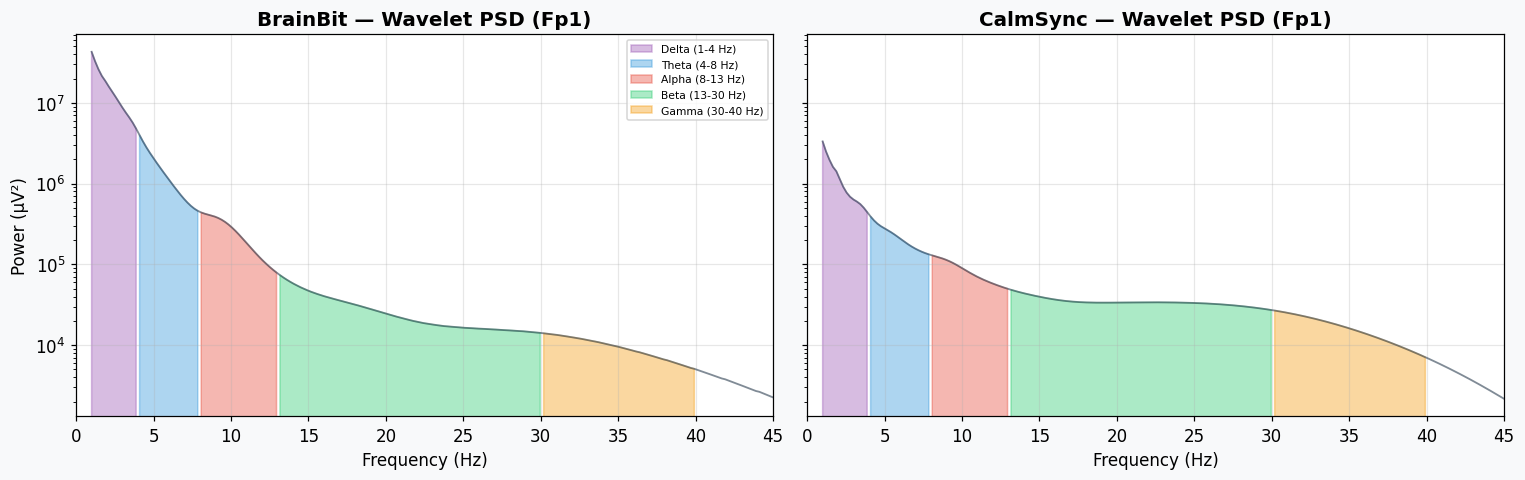

In [78]:
# ── Wavelet PSD for both devices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

for ax, (data, fs_dev, name) in zip(axes, [
    (bb_fp1, bb_fs, 'BrainBit'),
    (cs_fp1, cs_fs, 'CalmSync'),
]):
    f, p = wavelet_psd(data, fs_dev, freqs=np.linspace(1, 45, 200))

    ax.semilogy(f, p, color=C_SIGNAL, lw=1.2, alpha=0.6)
    for bname, (lo, hi) in BANDS.items():
        bmask = (f >= lo) & (f <= hi)
        ax.fill_between(f[bmask], p[bmask], alpha=0.4, color=BAND_COLORS[bname], label=bname)
    ax.set(xlabel='Frequency (Hz)', title=f'{name} — Wavelet PSD (Fp1)', xlim=(0, 45))

axes[0].set_ylabel('Power (µV²)')
axes[0].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

### 4d · Hilbert — Time-Resolved Band Power (first 30 seconds)

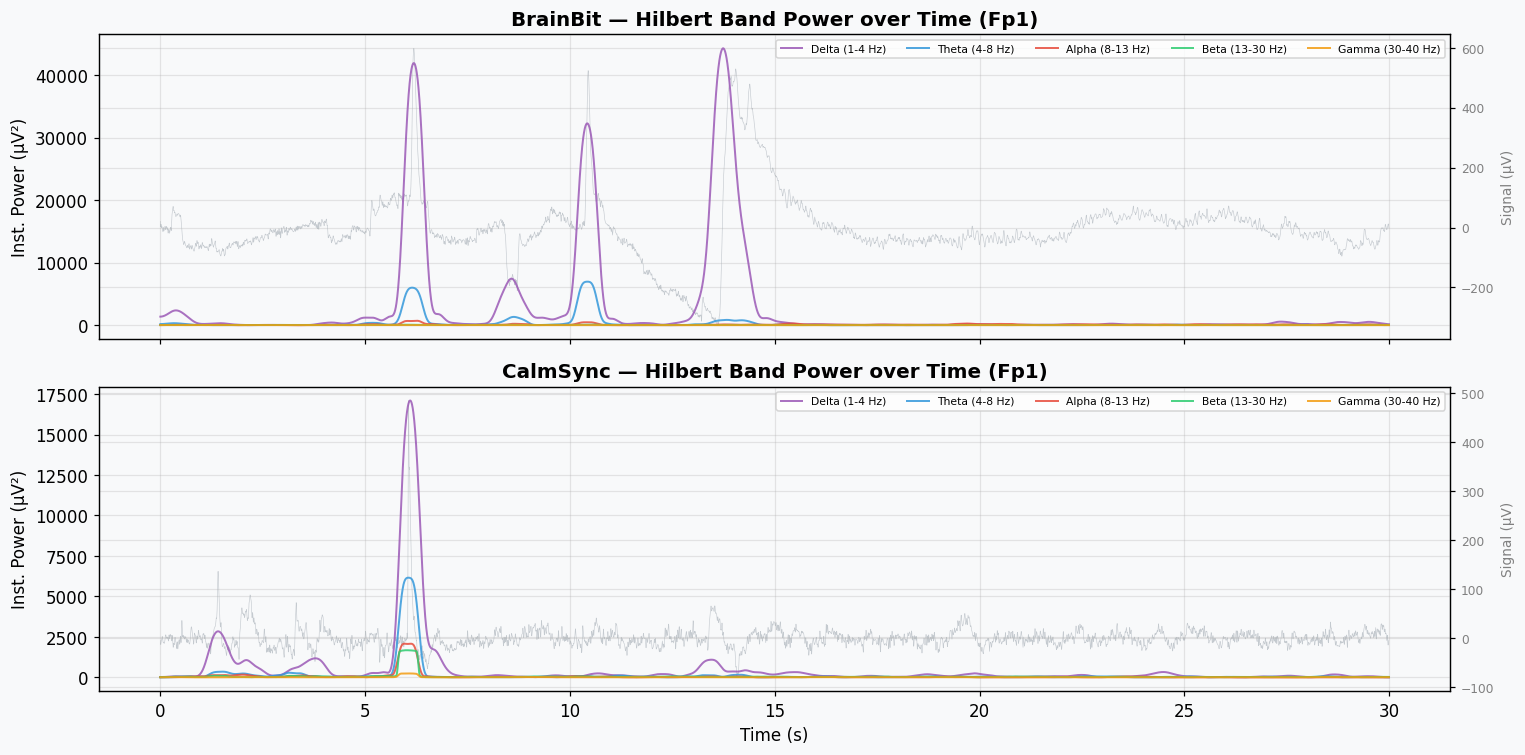

In [ ]:
# ── Hilbert time-resolved band power + raw signal overlay ────────────────────
def hilbert_envelope(x, fs, fmin, fmax):
    """Return instantaneous power time series for a band."""
    sos = signal.butter(4, [fmin, fmax], btype='band', fs=fs, output='sos')
    filt = signal.sosfiltfilt(sos, x)
    return np.abs(hilbert(filt))**2

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
window = 30  # show first 30 seconds

for ax, (data, fs_dev, name) in zip(axes, [
    (bb_fp1, bb_fs, 'BrainBit'),
    (cs_fp1, cs_fs, 'CalmSync'),
]):
    n_samp = int(window * fs_dev)
    t_plot = np.arange(n_samp) / fs_dev

    # raw signal on a twin axis (behind everything)
    ax_sig = ax.twinx()
    ax_sig.plot(t_plot, data[:n_samp], color=C_SIGNAL, lw=0.4, alpha=0.25, zorder=0)
    ax_sig.set_ylabel('Signal (µV)', color='grey', fontsize=9)
    ax_sig.tick_params(axis='y', labelcolor='grey', labelsize=8)

    # band power curves on top
    from scipy.ndimage import uniform_filter1d
    for bname, (lo, hi) in BANDS.items():
        env = hilbert_envelope(data[:n_samp], fs_dev, lo, hi)
        env_smooth = uniform_filter1d(env, size=int(0.5*fs_dev))
        ax.plot(t_plot, env_smooth, lw=1.3, color=BAND_COLORS[bname], label=bname, alpha=0.85, zorder=2)

    ax.set(ylabel='Inst. Power (µV²)', title=f'{name} — Hilbert Band Power over Time (Fp1)')
    ax.legend(fontsize=7, loc='upper right', ncol=5)
    ax.set_zorder(ax_sig.get_zorder() + 1)
    ax.patch.set_visible(False)  # make ax background transparent so signal shows through

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()


---
## 5 · Summary & Method Cheat Sheet

| Method | What it gives you | Time resolution? | Best for |
|--------|-------------------|:-:|----------|
| **FFT** | Raw periodogram | No (whole segment) | Seeing exact frequency content |
| **Welch** | Smooth PSD estimate | No (whole segment) | Quick spectral overview |
| **Hilbert** | Instantaneous power per band | **Yes** | Tracking power changes over time |
| **Wavelet** | Time-frequency power map | **Yes** | Non-stationary signals, seeing when frequencies come and go |

### Key Takeaways

1. **Power = mean squared amplitude.** For a sine wave: $A^2/2$. Simple.
2. **All four methods agree** on band power — they just have different trade-offs.
3. **Real EEG follows 1/f** — power drops with frequency (unlike our flat synthetic signal).
4. **Relative band power** lets you compare across devices with different amplifier scales.
5. **Hilbert is unique** — it gives you *time-resolved* power, so you can watch bands fluctuate moment to moment.
6. **Wavelet transform** gives you the full time-frequency picture — you can see both *which* frequencies and *when* they are active.

---
*Notebook created for the OSIS Lab — Band Power Lecture*